# P5.2 ⟨C⟩ = p. Check the above analytical result by simulation. [1P]
Local clustering coefficient of a vertex quantifies how close its neighbours are to being a clique(complete graph)

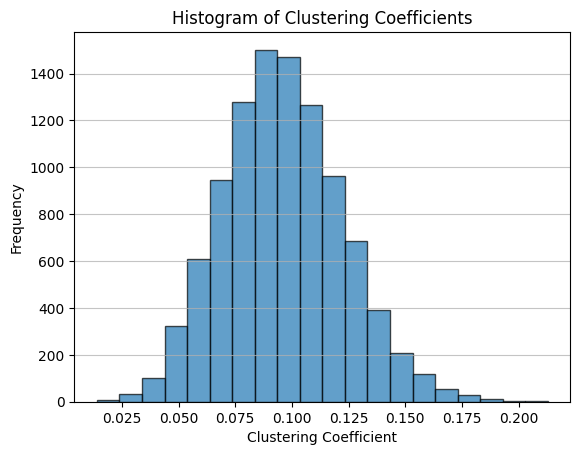

Mean Clustering Coefficient: 0.0961


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

def clustering_coefficient_simulation(num_trials, num_nodes, edge_prob):
    coefficients = []
    for _ in range(num_trials):
        G = nx.erdos_renyi_graph(num_nodes, edge_prob)
        coeff = nx.average_clustering(G)
        coefficients.append(coeff)
    return coefficients

def plot_histogram(data, num_bins):
    plt.hist(data, bins=num_bins, edgecolor='black', alpha=0.7)
    plt.title('Histogram of Clustering Coefficients')
    plt.xlabel('Clustering Coefficient')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

num_trials = 10000
num_nodes = 50
edge_prob = 0.1
num_bins = 20

clustering_coefficients = clustering_coefficient_simulation(num_trials, num_nodes, edge_prob)
plot_histogram(clustering_coefficients, num_bins)
print(f"Mean Clustering Coefficient: {np.mean(clustering_coefficients):.4f}")


# P5.3

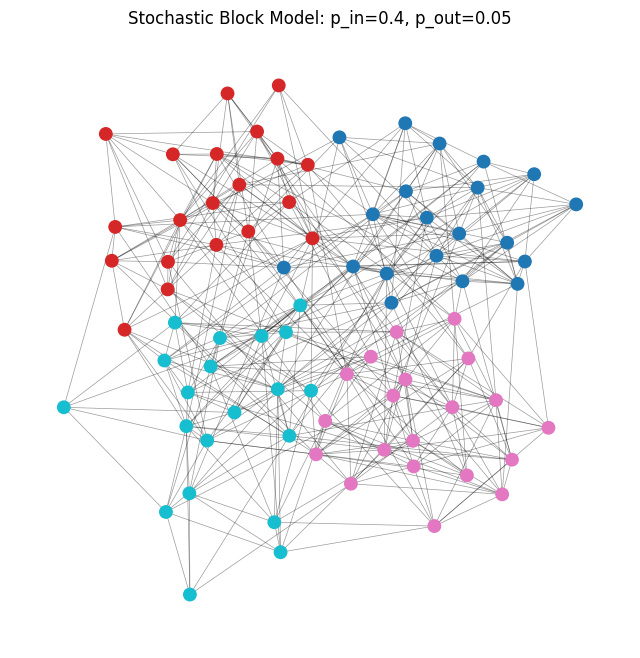

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

num_communities = 4
N = 20
sizes = [N] * num_communities

p_in = 0.4
p_out = 0.05


probs = [[p_in if i == j else p_out for j in range(num_communities)]
         for i in range(num_communities)]

G = nx.stochastic_block_model(sizes, probs, seed=42)

community_labels = []
for community_id, size in enumerate(sizes):
    community_labels.extend([community_id] * size)
nx.set_node_attributes(G, {i: community_labels[i] for i in G.nodes}, "community")

pos = nx.spring_layout(G, seed=42)

colors = [community_labels[node] for node in G.nodes]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_size=80, node_color=colors, cmap=plt.cm.tab10)
nx.draw_networkx_edges(G, pos, alpha=0.4, width=0.5)
plt.axis("off")
plt.title(f"p_in={p_in}, p_out={p_out}")
plt.show()


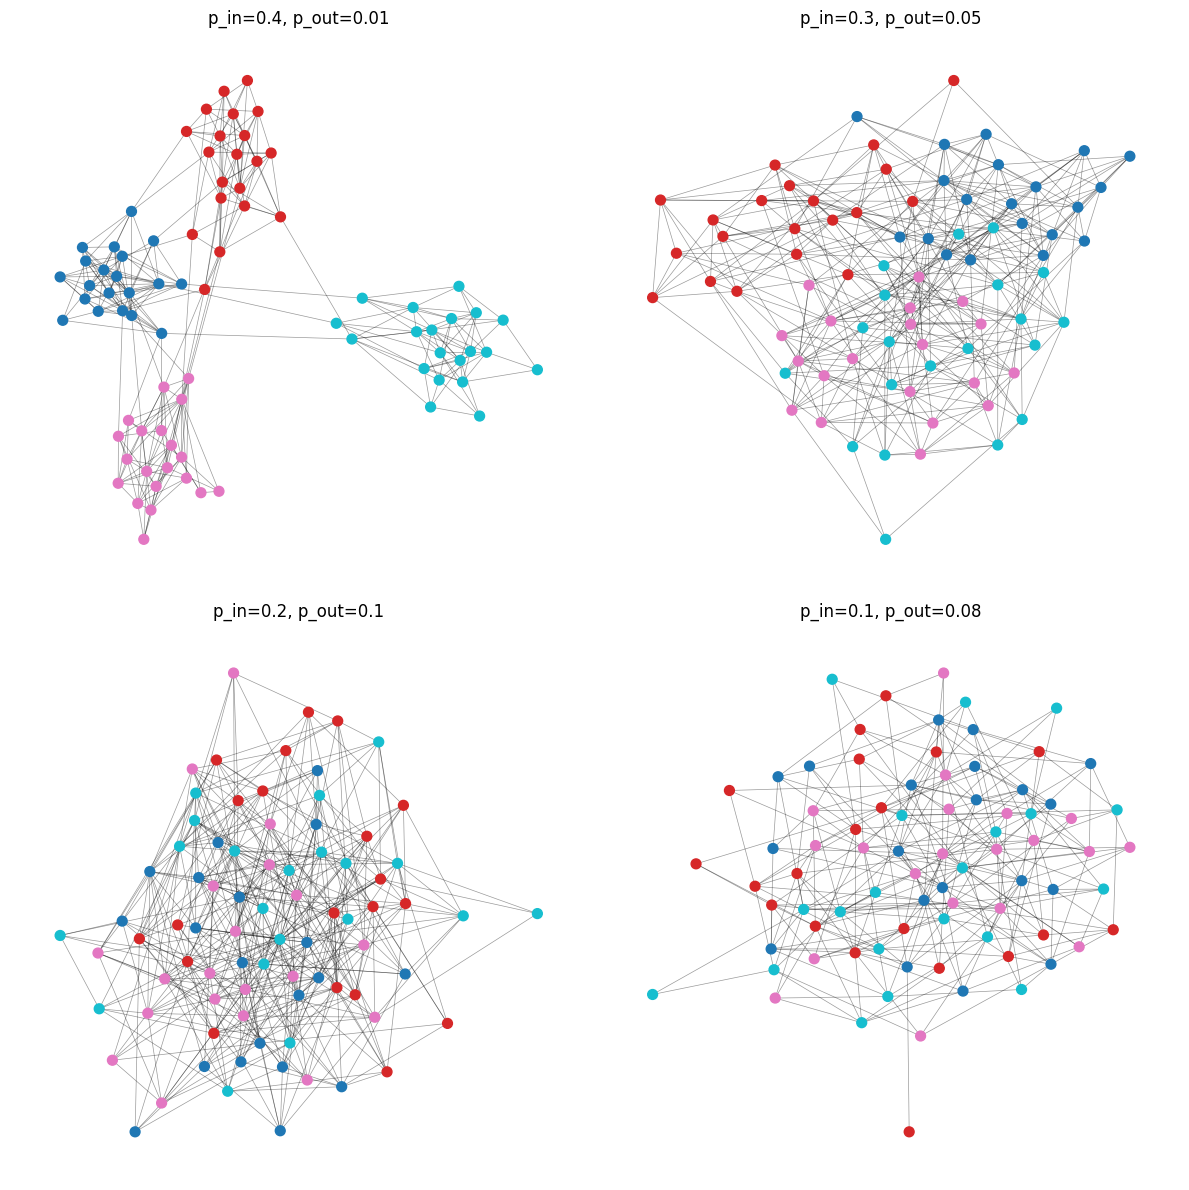

In [10]:
param_sets = [
    (0.4, 0.01),
    (0.3, 0.05),
    (0.2, 0.1),
    (0.1, 0.08)
]

plt.figure(figsize=(12, 12))

for i, (p_in, p_out) in enumerate(param_sets, start=1):
    probs = [[p_in if a == b else p_out for b in range(num_communities)]
             for a in range(num_communities)]
    G = nx.stochastic_block_model(sizes, probs, seed=42)
    pos = nx.spring_layout(G, seed=42)
    colors = [community_labels[node] for node in G.nodes]

    plt.subplot(2, 2, i)
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=colors, cmap=plt.cm.tab10)
    nx.draw_networkx_edges(G, pos, alpha=0.4, width=0.5)
    plt.title(f"p_in={p_in}, p_out={p_out}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# P5.4

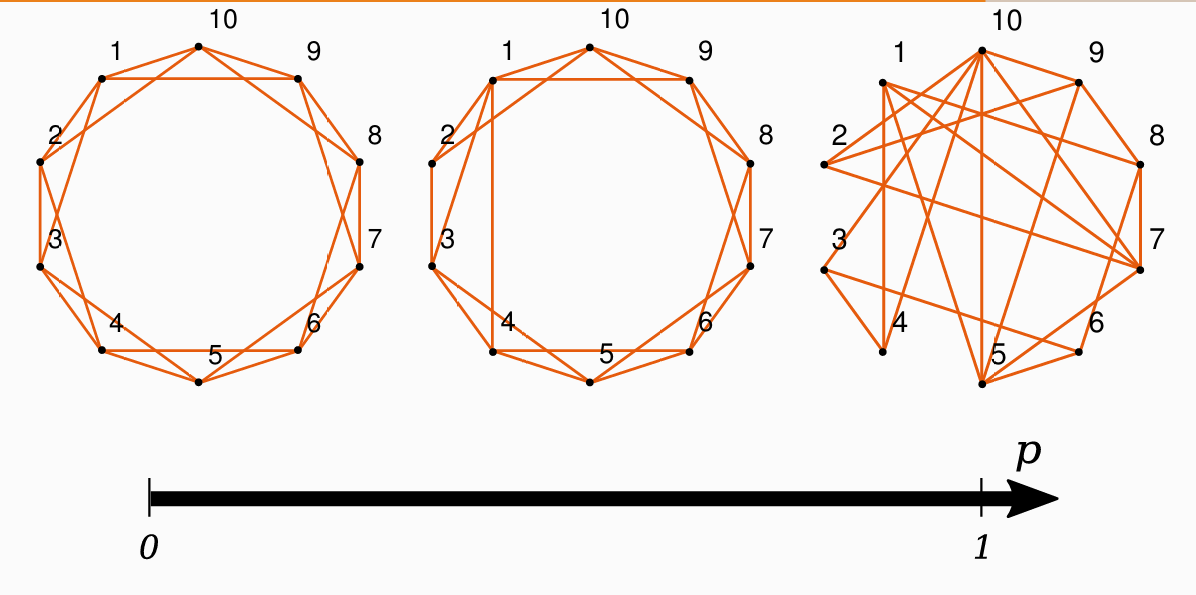

The WS model was created specifically to achieve:

High clustering like real-world social networks
Short path lengths after a few random rewirings

We start with the ring lattice, with connected nodes to k nearest neighbors. It has many triangles -> high clustering. We rewire each edge with proba p hence, less triangles and less averaged coeff of clustering

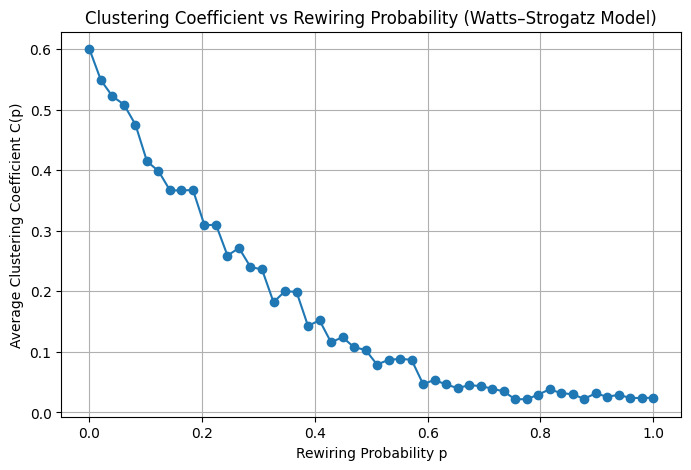

In [ ]:
%matplotlib inline
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

N = 200
k = 6
p_values = np.linspace(0, 1, 50)

clustering_values = []

for p in p_values:
    G = nx.watts_strogatz_graph(N, k, p)
    
    C = nx.average_clustering(G)
    clustering_values.append(C)

plt.figure(figsize=(8, 5))
plt.plot(p_values, clustering_values, marker='o')
plt.xlabel("Rewiring Probability p")
plt.ylabel("Average Clustering Coefficient C(p)")
plt.title("Clustering Coefficient vs Rewiring Probability (Watts–Strogatz Model)")
plt.grid(True)
plt.show()


# P5.6

In [10]:
def sample_poisson_degrees(n, lam, rng=None):
    """
    Sample a degree sequence of length n from Poisson(lam),
    enforcing an even total sum.
    """
    if rng is None:
        rng = np.random.default_rng()
    while True:
        deg = rng.poisson(lam, size=n)
        if deg.sum() % 2 == 0:
            return deg

def sample_power_law_degrees(n, gamma=2.5, k_min=1, k_max=None, rng=None):
    """
    Sample a power-law-like degree sequence using a truncated Zipf distribution.
    """
    if rng is None:
        rng = np.random.default_rng()
    if k_max is None:
        k_max = n - 1

    degrees = []
    while len(degrees) < n:
        k = rng.zipf(gamma)
        if k_min <= k <= k_max:
            degrees.append(k)
    degrees = np.array(degrees)

    if degrees.sum() % 2 == 1:
        i = rng.integers(0, n)
        if degrees[i] < k_max:
            degrees[i] += 1
        elif degrees[i] > k_min:
            degrees[i] -= 1

    return degrees

def configuration_model_graph(degrees, seed=None, simple=True):
    """
    Configuration model using networkx:
    - build a multigraph
    - optionally simplify to a simple graph (no loops, no multi-edges).
    """
    G_multi = nx.configuration_model(degrees, seed=seed)
    if not simple:
        return G_multi

    G = nx.Graph(G_multi)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def degree_stats(G):
    """
    Return (mean_degree, std_degree) for graph G.
    """
    degs = np.array([d for _, d in G.degree()])
    return degs.mean(), degs.std()



In [11]:
def convergence_experiment_cases(
    n_values,
    num_samples,
    cases,
    seed=123,
    simple=True
):
    """
    Run convergence experiment for multiple (distribution, parameter) cases.
    """
    rng = np.random.default_rng(seed)
    results = {}

    for case in cases:
        name = case["name"]
        dist = case["dist"]
        params = case.get("params", {})

        data = {
            "n_values": n_values,
            "all_means": [],
            "all_stds": [],
            "mean_obs": [],
            "mean_std_between_graphs": [],
            "std_obs": [],
            "std_std_between_graphs": [],
            "target_mean": [],
            "target_std": [],
        }

        for n in n_values:
            mean_list = []
            std_list = []

            for _ in range(num_samples):
                if dist == "poisson":
                    lam = params["lam"]
                    degrees = sample_poisson_degrees(n, lam, rng)
                    target_mean = lam
                    target_std = np.sqrt(lam)
                elif dist == "powerlaw":
                    gamma = params["gamma"]
                    k_min = params.get("k_min", 1)
                    degrees = sample_power_law_degrees(
                        n, gamma=gamma, k_min=k_min, k_max=n-1, rng=rng
                    )
                    target_mean = None
                    target_std = None
                else:
                    raise ValueError(f"Unknown dist: {dist}")

                G = configuration_model_graph(
                    degrees,
                    seed=int(rng.integers(0, 1e9)),
                    simple=simple
                )
                m, s = degree_stats(G)
                mean_list.append(m)
                std_list.append(s)

            mean_list = np.array(mean_list)
            std_list = np.array(std_list)

            data["all_means"].append(mean_list)
            data["all_stds"].append(std_list)
            data["mean_obs"].append(mean_list.mean())
            data["mean_std_between_graphs"].append(mean_list.std())
            data["std_obs"].append(std_list.mean())
            data["std_std_between_graphs"].append(std_list.std())
            data["target_mean"].append(target_mean)
            data["target_std"].append(target_std)

            print(f"{name} | N={n:5d} | "
                  f"mean: {mean_list.mean():.3f}, std: {std_list.mean():.3f}")

        results[name] = data

    return results


In [12]:
n_values = [100, 300, 1000, 3000, 10000]
cases = [
    {"name": "Poisson lambda=2", "dist": "poisson", "params": {"lam": 2}},
    {"name": "Poisson lambda=4", "dist": "poisson", "params": {"lam": 4}},
    {"name": "Poisson lambda=8", "dist": "poisson", "params": {"lam": 8}},
    {"name": "Power law gamma=2.5", "dist": "powerlaw", "params": {"gamma": 2.5, "k_min": 1}},
]

results = convergence_experiment_cases(
    n_values=n_values,
    num_samples=50,
    cases=cases,
    simple=True
)


Poisson lambda=2 | N=  100 | mean: 1.938, std: 1.347
Poisson lambda=2 | N=  300 | mean: 1.996, std: 1.407
Poisson lambda=2 | N= 1000 | mean: 1.995, std: 1.405
Poisson lambda=2 | N= 3000 | mean: 1.995, std: 1.411
Poisson lambda=2 | N=10000 | mean: 2.002, std: 1.415
Poisson lambda=4 | N=  100 | mean: 3.844, std: 1.894
Poisson lambda=4 | N=  300 | mean: 3.963, std: 1.948
Poisson lambda=4 | N= 1000 | mean: 3.978, std: 1.986
Poisson lambda=4 | N= 3000 | mean: 3.993, std: 1.995
Poisson lambda=4 | N=10000 | mean: 3.999, std: 1.998
Poisson lambda=8 | N=  100 | mean: 7.605, std: 2.576
Poisson lambda=8 | N=  300 | mean: 7.884, std: 2.792
Poisson lambda=8 | N= 1000 | mean: 7.937, std: 2.803
Poisson lambda=8 | N= 3000 | mean: 7.977, std: 2.815
Poisson lambda=8 | N=10000 | mean: 7.997, std: 2.829
Power law gamma=2.5 | N=  100 | mean: 1.677, std: 1.951
Power law gamma=2.5 | N=  300 | mean: 1.812, std: 3.064
Power law gamma=2.5 | N= 1000 | mean: 1.824, std: 4.014
Power law gamma=2.5 | N= 3000 | mean:

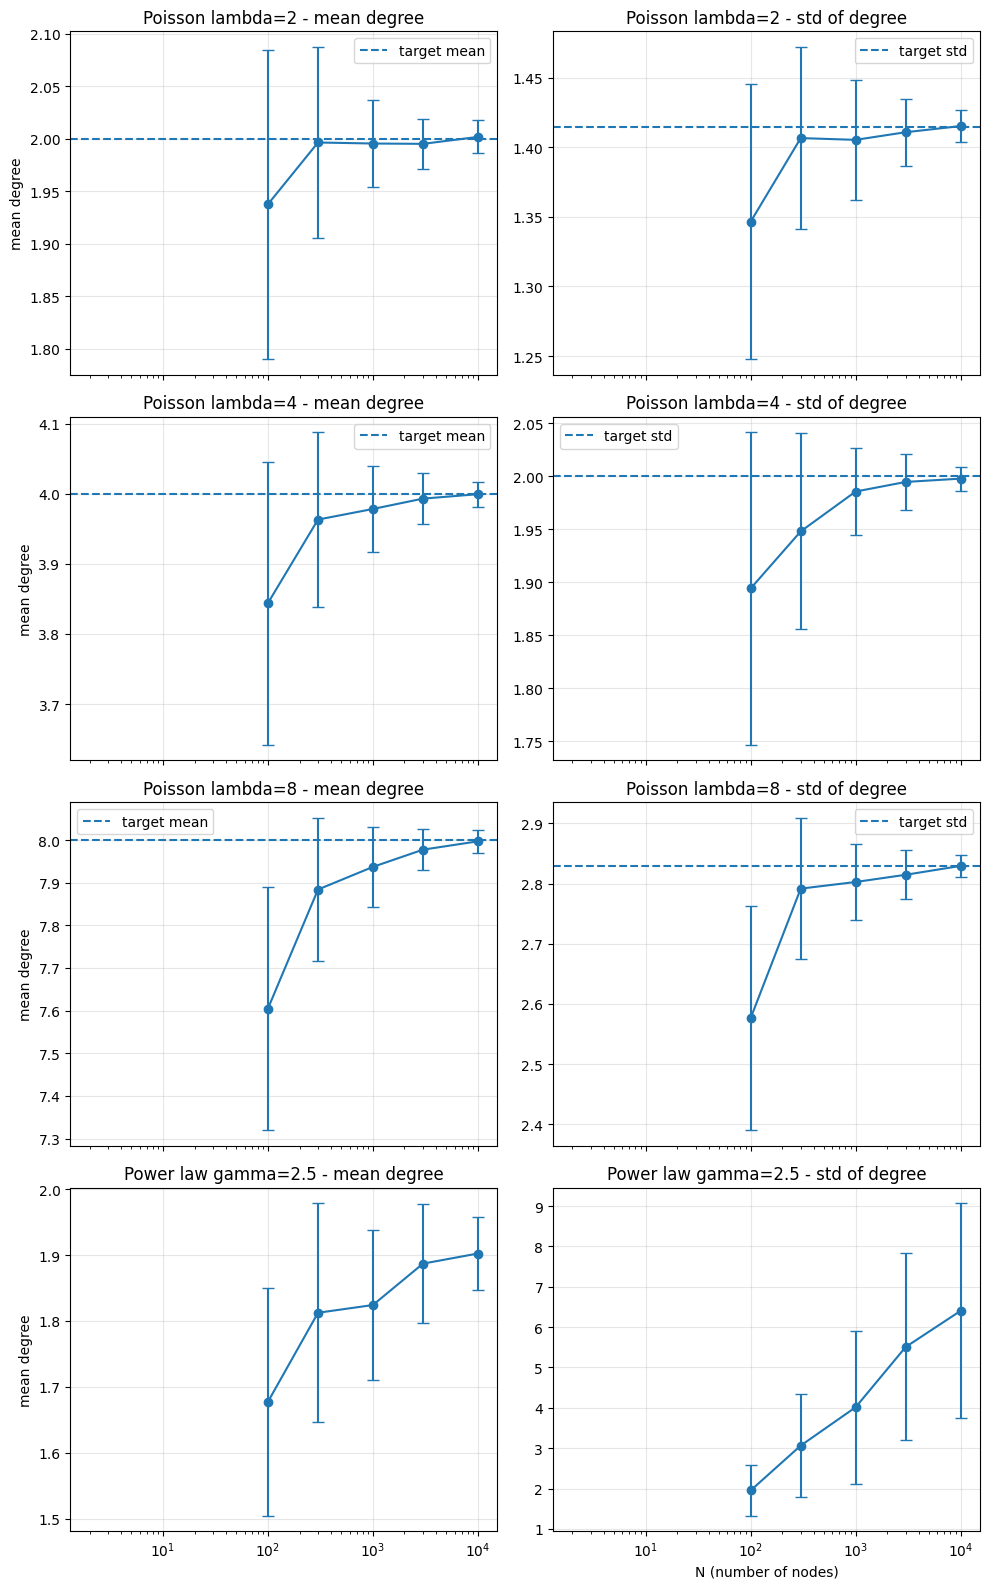

In [21]:
def plot_convergence_results(results, logx=True):
    num_cases = len(results)
    fig, axes = plt.subplots(
        num_cases, 2, figsize=(10, 4 * num_cases), sharex=True
    )
    if num_cases == 1:
        axes = np.array([axes])

    for row, (name, data) in enumerate(results.items()):
        n_values = data["n_values"]
        mean_obs = np.array(data["mean_obs"])
        mean_err = np.array(data["mean_std_between_graphs"])
        std_obs = np.array(data["std_obs"])
        std_err = np.array(data["std_std_between_graphs"])
        target_mean = data["target_mean"]
        target_std = data["target_std"]

        ax = axes[row, 0]
        ax.errorbar(n_values, mean_obs, yerr=mean_err,
                    marker="o", capsize=4)
        if all(t is not None for t in target_mean):
            ax.axhline(target_mean[0], linestyle="--", label="target mean")
            ax.legend()
        ax.set_title(f"{name} - mean degree")
        ax.set_ylabel("mean degree")
        if logx:
            ax.set_xscale("log")
        ax.grid(True, alpha=0.3)

        ax = axes[row, 1]
        ax.errorbar(n_values, std_obs, yerr=std_err,
                    marker="o", capsize=4)
        if all(t is not None for t in target_std):
            ax.axhline(target_std[0], linestyle="--", label="target std")
            ax.legend()
        ax.set_title(f"{name} - std of degree")
        if row == num_cases - 1:
            ax.set_xlabel("N (number of nodes)")
        if logx:
            ax.set_xscale("log")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
plot_convergence_results(results, logx=True)

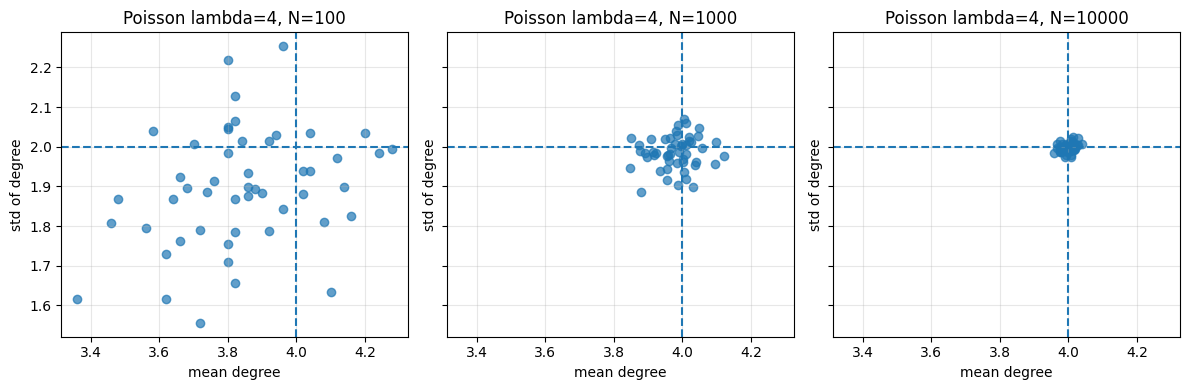

In [14]:
def plot_scatter_for_case(results, case_name, n_indices=None):
    """
    Plot scatter of (mean, std) for one chosen case,
    for several values of N.
    """
    data = results[case_name]
    n_values = data["n_values"]

    if n_indices is None:
        n_indices = [0, len(n_values) // 2, len(n_values) - 1]

    k = len(n_indices)
    fig, axes = plt.subplots(1, k, figsize=(4 * k, 4),
                             sharex=True, sharey=True)

    if k == 1:
        axes = [axes]

    for ax, idx in zip(axes, n_indices):
        N = n_values[idx]
        means = data["all_means"][idx]
        stds = data["all_stds"][idx]
        t_mean = data["target_mean"][idx]
        t_std = data["target_std"][idx]

        ax.scatter(means, stds, alpha=0.7)
        if t_mean is not None:
            ax.axvline(t_mean, linestyle="--")
        if t_std is not None:
            ax.axhline(t_std, linestyle="--")

        ax.set_title(f"{case_name}, N={N}")
        ax.set_xlabel("mean degree")
        ax.set_ylabel("std of degree")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
plot_scatter_for_case(results, "Poisson lambda=4")
